# Make Figures 5 and 6 for S22/G102

In [12]:
import jax
from jax import config
config.update("jax_enable_x64", True)

import jax.numpy as jnp
import numpy as np
import astropy.units as u
from chromatic import *
import arviz as az
import shone
import corner
from fleck.jax import ActiveStar
from bt_settl import get_interp_stellar_spectrum_3d

# Create custom binned bin edges
wl_min, wl_max = 0.7, 1.7
n_points = 10000

binned_bin_edges = np.geomspace(wl_min, wl_max, n_points + 1)

binned_wavelengths = (binned_bin_edges[:-1] + binned_bin_edges[1:]) / 2.0

print(f"Creating custom binned grid with {n_points} points from {wl_min} to {wl_max} µm")
print(f"Binned bin edges shape: {len(binned_bin_edges)}")
print(f"Binned wavelengths shape: {len(binned_wavelengths)}")

# Step 2: Create the interpolation grid using these custom bin edges
print("\nCreating BT-Settl 3D interpolation grid with custom binning...")
panchromatic_btsettl_grid = get_interp_stellar_spectrum_3d(binned_bin_edges)
panchromatic_wavelengths = binned_wavelengths
panchromatic_bin_edges = binned_bin_edges

print(f"\nWavelength range: {panchromatic_wavelengths[0]:.3f} - {panchromatic_wavelengths[-1]:.3f} µm")
print(f"Number of wavelength points: {len(panchromatic_wavelengths)}")
print("\nGrid creation complete!")

def get_BTSettl_spectrum_jax(T, 
                             metallicity=0, data_wave=None,
                             grid=panchromatic_btsettl_grid, **kwargs):
    """
    Get BT-Settl spectrum for given temperature, logg, and metallicity.
    
    Parameters:
    T : effective temperature (K)
    metallicity : metallicity ([M/H])
    grid : 3D interpolation function from get_interp_stellar_spectrum_3d
    
    Returns:
    flux_jax : flux array (erg/cm^2/s/Å)
    """
    
    gridspec = grid(
        jnp.array(T, dtype=jnp.float64),
        jnp.array(metallicity, dtype=jnp.float64)
    )
    
    flux_jax = jnp.array(gridspec, dtype=jnp.float64)

    binned_flux = shone.bin_spectrum(data_wave, panchromatic_wavelengths, flux_jax)
    
    return data_wave, binned_flux

def breathing_model_jax(phase, b1, b2, b3, b4):

    phase = jnp.array(phase)
    _breathing = 1. + (b1 * phase) + (b2 * phase**2.) + (b3 * phase**3.) + (b4 * phase**4.)
    breathing = _breathing/jnp.mean(_breathing)
    
    return jnp.array(breathing)

def ramp_model_jax(phase, r1, r2, r3):

    phase = jnp.array(phase)
    _ramp = 1. - jnp.exp( (-r1 * phase) + r2) + (r3 * phase)
    ramp = _ramp/jnp.mean(_ramp)
    
    return jnp.array(ramp)

visits = {
    'S22': {
        'Grism': 'G102',
        'BJD_times': np.array(pd.read_csv('../../data/S22_bjdtimes.csv')['BJD'][:]) * u.day,
        'time_lower': 2459684.215 * u.day,
        'time_upper': 2459684.243 * u.day,
        'T0 (BJD_TDB)': 2459684.4959 * u.day, # This is 27 planetary orbits after the first transit, + 0.0054 days (the transit arrived 7 minutes late)
        'exp (s)': 9.67632 * u.s,
        'native resolution': 24.6 * u.angstrom
    }
}

Creating custom binned grid with 10000 points from 0.7 to 1.7 µm
Binned bin edges shape: 10001
Binned wavelengths shape: 10000

Creating BT-Settl 3D interpolation grid with custom binning...

Wavelength range: 0.700 - 1.700 µm
Number of wavelength points: 10000

Grid creation complete!


🌈🤖 It looks like you're trying to bin in wavelength for a
`Rainbow` object that might not be normalized. In the
current version of `chromatic`, binning before normalizing
might give inaccurate results if the typical uncertainty
varies strongly with wavelength.

Please consider normalizing first, for example with
`rainbow.normalize().bin(...)`
so that all uncertainties will effectively be relative,
and the inverse variance weighting used for binning
wavelengths together will give more reasonable answers.

If you really need to bin before normalizing, please submit
an Issue at github.com/zkbt/chromatic/, and we'll try to
prioritize implementing a statistically sound solution as
soon as possible!



  0%|          | 0/160 [00:00<?, ?it/s]

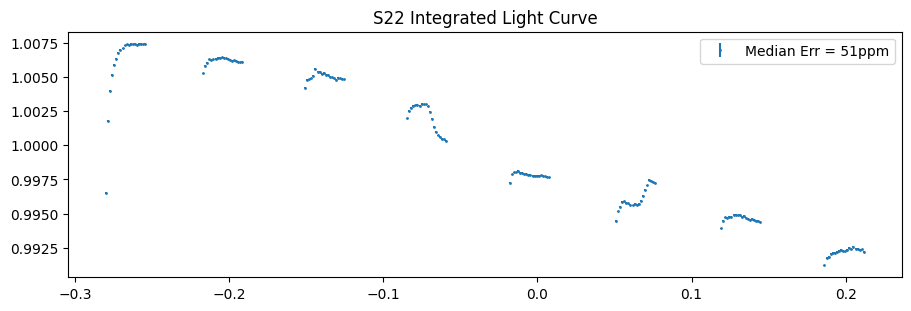

<Figure size 640x480 with 0 Axes>

In [13]:
visit = 'S22'

orbits_to_exclude = np.array([0,2,7])
lc_index = 1 if visit=='F21' else 0
bin_edges = jnp.array([0.79,1.135,1.64]) * u.micron

predicted_T0 = visits[f'{visit}']['T0 (BJD_TDB)'].value
binwidth = visits[f'{visit}']['native resolution']
exptime = visits[f'{visit}']['exp (s)']
grism = visits[f'{visit}']['Grism']

rainbow = read_rainbow(f'../../data/{visit}_scan-combined_trimmed_pacman_spec.rainbow.npy')
binned_for_model = rainbow.bin(wavelength_edges=bin_edges)
fleck_wavelengths = binned_for_model.wavelength.value

integrated_flux = np.trapz(rainbow.flux.value,x=rainbow.wavelength.value,axis=0)

img_date = rainbow.time.value
data_flux = integrated_flux/integrated_flux.mean()
relative_err = np.sqrt(integrated_flux/rainbow.nwave)/integrated_flux
time_from_T0 = img_date - predicted_T0

plt.figure(figsize=(9,3))
plt.errorbar(time_from_T0,data_flux,relative_err,
             label=f'Median Err = {int(np.nanmedian(relative_err)*1e6) }ppm',
            fmt='o',ms=1)
plt.legend()
plt.title(f'{visit} Integrated Light Curve')
plt.show()
plt.clf()

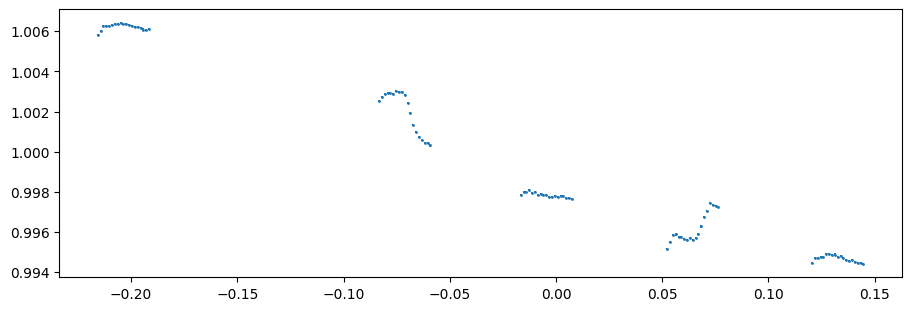

<Figure size 640x480 with 0 Axes>

In [14]:
# Label the orbits
orbit = np.zeros_like(img_date)
for j in range(len(img_date)):
    if j >= 1:
        if (img_date[j] - img_date[j - 1]) > 0.01:
            orbit[j] = (orbit[j - 1] + 1)
        else:
            orbit[j] = orbit[j - 1]

# Trim the first point from each orbit
ref_time = []
for o in np.unique(orbit):
    first_index = np.where(orbit == o)[0][0]
    ref_time.append(img_date[first_index])
    data_flux[first_index] = np.nan  # Set the first point of each subsequent orbit to np.nan
    relative_err[first_index] = np.nan
    img_date[first_index] = np.nan
    time_from_T0[first_index] = np.nan

# Set data to nan if it was in the pre-defined list of orbits to exclude
for orbit_to_exclude in orbits_to_exclude:
    data_flux[orbit == orbit_to_exclude] = np.nan
    relative_err[orbit == orbit_to_exclude] = np.nan
    img_date[orbit == orbit_to_exclude] = np.nan
    time_from_T0[orbit == orbit_to_exclude] = np.nan

plt.figure(figsize=(9,3) )
plt.errorbar(time_from_T0,data_flux,yerr=relative_err,fmt='o',ms=1)
plt.show()
plt.clf()

# Populate ramp_phase time arrays
phase_list=[]
for o in [0,1,2,3,4,5,6,7]:
    rphase = (img_date[orbit==o] - ref_time[o]) / 0.066
    phase_list.append(rphase)
ramp_phase = np.concatenate(phase_list)
breathing_phase = ( (img_date-ref_time[0]+0.02) / 0.066 ) % 1

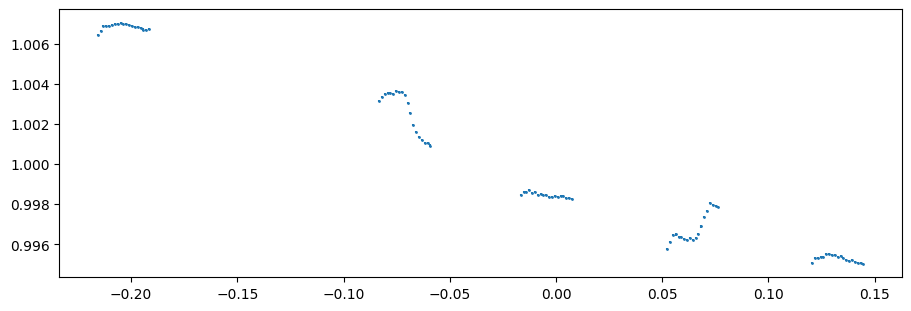

<Figure size 640x480 with 0 Axes>

In [15]:
# Convert all arrays to JAX arrays
_data_flux = jnp.array( data_flux[~np.isnan(time_from_T0)] )
data_flux = _data_flux[~jnp.isnan(_data_flux)]
_relative_err = jnp.array(relative_err[~np.isnan(time_from_T0)] )
relative_err = _relative_err[~jnp.isnan(_data_flux)]
_img_date = jnp.array(img_date[~np.isnan(time_from_T0)] )
img_date = _img_date[~jnp.isnan(_data_flux)]
_time_from_T0 = jnp.array(time_from_T0[~np.isnan(time_from_T0)] )
time_from_T0 = _time_from_T0[~jnp.isnan(_data_flux)]
_ramp_phase = jnp.array(ramp_phase[~np.isnan(ramp_phase)] )
ramp_phase = _ramp_phase[~jnp.isnan(_data_flux)]
_breathing_phase = jnp.array(breathing_phase[~np.isnan(breathing_phase)] )
breathing_phase = _breathing_phase[~jnp.isnan(_data_flux)]

normalized_data_flux = data_flux/jnp.mean(data_flux)
normalized_relative_err = relative_err*normalized_data_flux

plt.figure(figsize=(9,3) )
plt.errorbar(time_from_T0,normalized_data_flux,yerr=normalized_relative_err,fmt='o',ms=1)
plt.show()
plt.clf()

In [16]:
default_params={
    # Ramp Model Parameters
    'r_1': 14.149,
    'r_2': -6.58,
    'r_3': 0.0153,
    #Breathing params
    'b_1':-0.0097,
    'b_2':-0.0334,
    'b_3':0.056,
    'b_4':-0.03,
    # Planet parameters
    'Mp':8.0,
    'i_planet':89.5,
    'P_orb':8.463,
    't_0':0.00048,
    'rp_rstar': 0.0465,
    'a_rstar': 19.15,
    'ecc': 0.0,
    'u_1':0.35,
    'u_2':0.15,
    # Stellar parameters
    'log_g':4.5,
    'i_star':89.5,
    'P_rot':4.86,
    'Rs':0.8,
    'Ms':0.6,
    'metallicity':0.0,
    # Spot Parameters
    'T_phot': 3891,
    'T_spot': 3020,
    'limb_spot_lon':-1.305,
    'limb_spot_lat':0.8,
    'limb_spot_rad':0.278,
    'chord_spot_lon_1':0.056,
    'chord_spot_lat_1':1.595,
    'chord_spot_rad_1':0.126,
    'chord_spot_lon_2':0.85,
    'chord_spot_lat_2':1.699,
    'chord_spot_rad_2':0.059,
    # Model meta-parameters
    'beta':0.29,
}

In [17]:
model_designations = [
    'S22_60000samples_12chains_3spots_whitelight_2025_12_30',
                      ]

In [18]:
for model_designation in model_designations:

    print(f'model designation: {model_designation}')
    # load the results from the NetCDF file
    result = az.from_netcdf(f'{model_designation}')

    print(az.summary(result))

model designation: S22_60000samples_12chains_3spots_whitelight_2025_12_30
                   mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
b_1               0.017  0.022  -0.023    0.060      0.003    0.001      65.0   
b_2              -0.123  0.067  -0.254   -0.007      0.008    0.003      62.0   
b_3               0.178  0.088   0.027    0.352      0.011    0.004      61.0   
b_4              -0.087  0.042  -0.171   -0.016      0.005    0.002      61.0   
beta              0.459  0.032   0.400    0.520      0.001    0.000    1127.0   
chord_spot_lat_1  1.548  0.026   1.504    1.608      0.003    0.002      82.0   
chord_spot_lat_2  1.701  0.027   1.653    1.747      0.003    0.001      96.0   
chord_spot_lon_1  0.066  0.013   0.045    0.089      0.000    0.000    1611.0   
chord_spot_lon_2  0.850  0.005   0.842    0.860      0.000    0.000     563.0   
chord_spot_rad_1  0.171  0.026   0.112    0.214      0.003    0.002      66.0   
chord_spot_rad_2  0.065  0.018   0.

In [19]:
for model_designation in model_designations:

    print(f'model designation: {model_designation}')
    # load the results from the NetCDF file
    result = az.from_netcdf(f'{model_designation}')
    
    # examine the Leave-One-Out (LOO) summary
    print(f'LOO for {model_designation}')
    loo = az.loo(result, pointwise=True)
    print(loo)

model designation: S22_60000samples_12chains_3spots_whitelight_2025_12_30
LOO for S22_60000samples_12chains_3spots_whitelight_2025_12_30


/opt/anaconda3/envs/pyjax312/lib/python3.12/site-packages/arviz/stats/stats.py:1057: RuntimeWarning: overflow encountered in exp
  weights = 1 / np.exp(len_scale - len_scale[:, None]).sum(axis=1)
/opt/anaconda3/envs/pyjax312/lib/python3.12/site-packages/numpy/core/_methods.py:49: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


Computed from 720000 posterior samples and 114 observations log-likelihood matrix.

         Estimate       SE
elpd_loo   886.21     8.01
p_loo       16.23        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      114  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



model designation: S22_60000samples_12chains_3spots_whitelight_2025_12_30


/opt/anaconda3/envs/pyjax312/lib/python3.12/site-packages/corner/core.py:133: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(


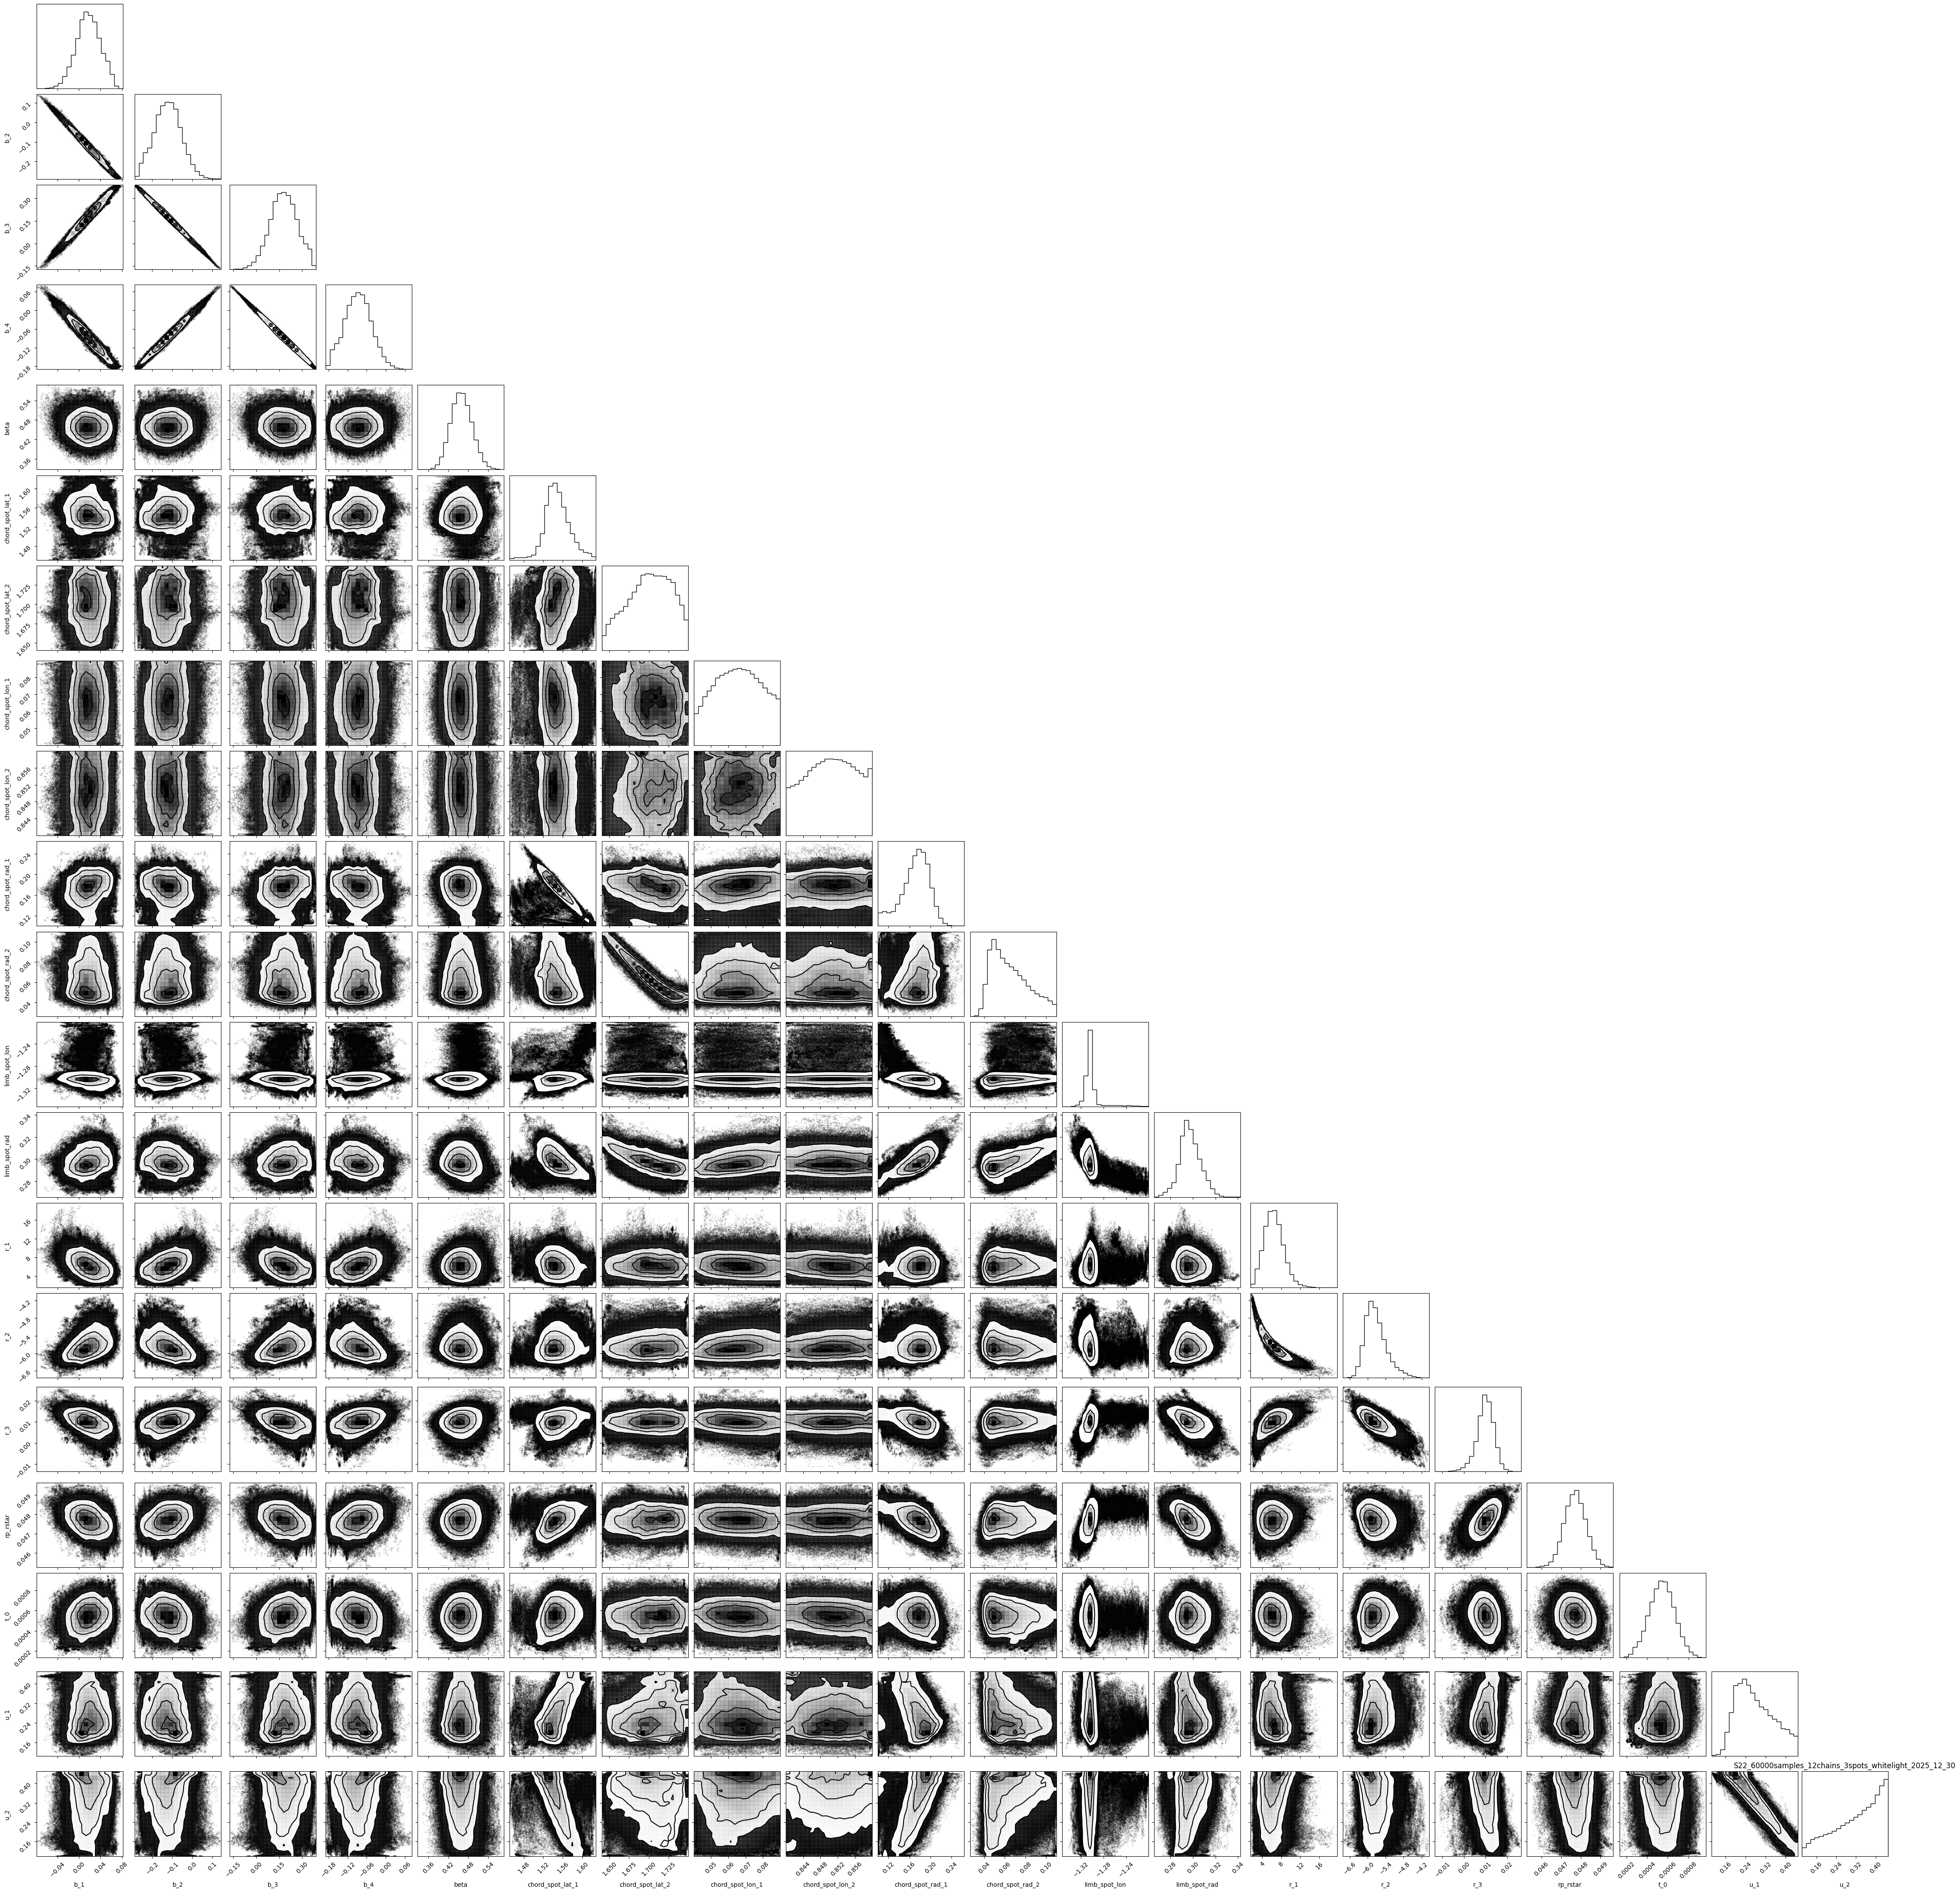

In [20]:
for model_designation in model_designations:

    print(f'model designation: {model_designation}')
    # load the results from the NetCDF file
    result = az.from_netcdf(f'{model_designation}')
    
    # make a corner plot of the posterior distributions
    corner.corner(
        result,
    )
    plt.title(f'{model_designation}')
    plt.show()
    # plt.savefig(f'{model_designation}_corner.png',dpi=200)

In [21]:
# 'Examine the Leave-One-Out (LOO) summary'
# loo = az.loo(result, pointwise=True)
# loo

### Print and plot the median parameter measurements

In [22]:
# final_median_params = az.summary(result,stat_focus='median')['median']

## Print and plot the Maximum Likelihood Estimate results

{'b_1': 0.01617068829559798, 'b_2': -0.12626968872613448, 'b_3': 0.18427404402732506, 'b_4': -0.09088383651306103, 'beta': 0.4594917921001804, 'chord_spot_lat_1': 1.5385545044865288, 'chord_spot_lat_2': 1.7283827424381577, 'chord_spot_lon_1': 0.05803645371799725, 'chord_spot_lon_2': 0.8478348732970743, 'chord_spot_rad_1': 0.17833845043410293, 'chord_spot_rad_2': 0.05181770787858634, 'limb_spot_lon': -1.3057860520022513, 'limb_spot_rad': 0.29035246098745937, 'r_1': 6.293687588462516, 'r_2': -5.792185662888072, 'r_3': 0.012377921908918421, 'rp_rstar': 0.047956319192897605, 't_0': 0.0005769681906956359, 'u_1': 0.27747037637547933, 'u_2': 0.3362349079576747}


/var/folders/vq/zxq380ws52q37mjjtbt9c7rh0000gp/T/ipykernel_23569/1954537422.py:228: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


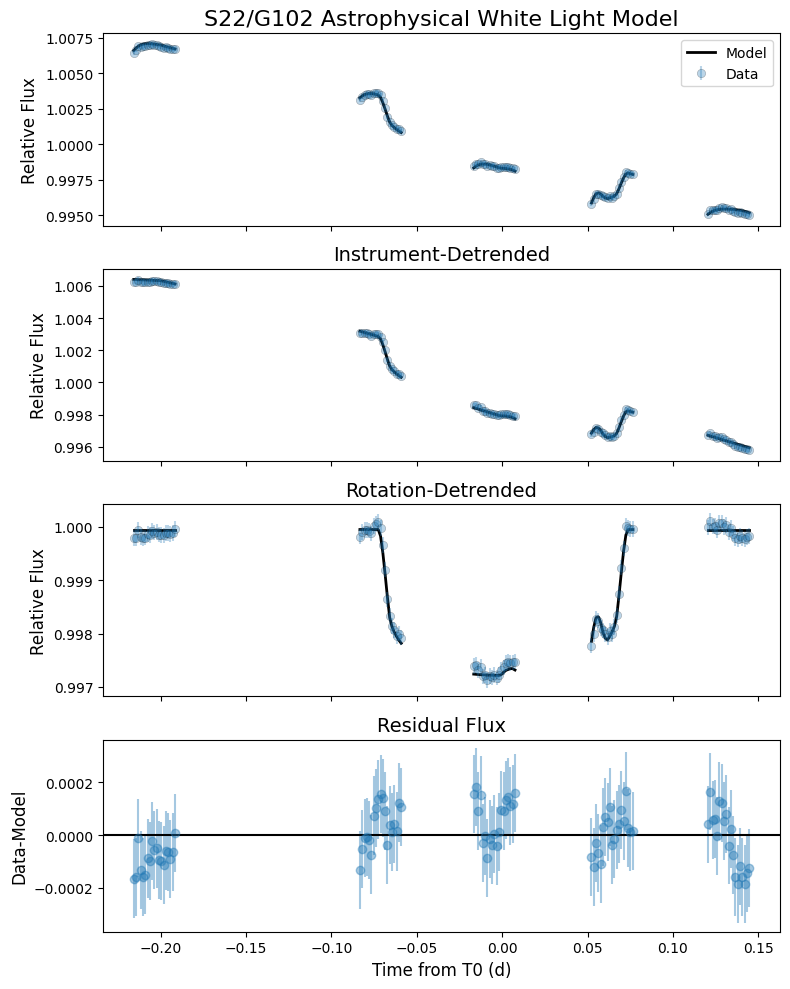

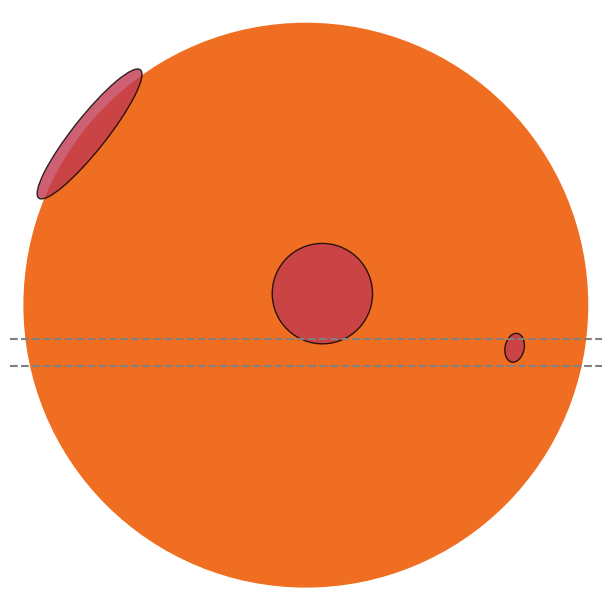

In [29]:
def calculate_model(parameter_dict,relative_flux):
    
    params = parameter_dict

    # Calculate systematics model
    ramp = ramp_model_jax(phase=ramp_phase,
                    r1=jnp.asarray(params.get('r_1',default_params['r_1']), dtype=jnp.float64),
                    r2=jnp.asarray(params.get('r_2',default_params['r_2']), dtype=jnp.float64),
                    r3=jnp.asarray(params.get('r_3',default_params['r_3']), dtype=jnp.float64) )
    breathing = breathing_model_jax(phase=breathing_phase,
                              b1=jnp.asarray(params.get('b_1',default_params['b_1']), dtype=jnp.float64),
                              b2=jnp.asarray(params.get('b_2',default_params['b_2']), dtype=jnp.float64),
                              b3=jnp.asarray(params.get('b_3',default_params['b_3']), dtype=jnp.float64),
                              b4=jnp.asarray(params.get('b_4',default_params['b_4']), dtype=jnp.float64))

    _systematics = (breathing * ramp)
    systematics = _systematics/jnp.mean(_systematics)
    
    # Update Planet Parameters
    planet_parameters = dict(
        inclination = jnp.radians(default_params['i_planet']),
        a = jnp.asarray(params.get('a_rstar',default_params['a_rstar']), dtype=jnp.float64),
        rp = jnp.asarray(params.get('rp_rstar',default_params['rp_rstar']), dtype=jnp.float64),
        period = jnp.asarray(params.get('P_orb',default_params['P_orb']), dtype=jnp.float64),
        t0 = jnp.asarray(params.get('t_0',default_params['t_0']), dtype=jnp.float64),
        ecc = jnp.asarray(params.get('ecc',default_params['ecc']), dtype=jnp.float64),
        u1 = jnp.asarray(params.get('u_1',default_params['u_1']), dtype=jnp.float64),
        u2 = jnp.asarray(params.get('u_2',default_params['u_2']), dtype=jnp.float64),
    )
    no_planet_params = dict(
        inclination = jnp.radians(default_params['i_planet']),
        a = jnp.asarray(params.get('a_rstar',default_params['a_rstar']), dtype=jnp.float64),
        rp = 0.0,
        period = jnp.asarray(params.get('P_orb',default_params['P_orb']), dtype=jnp.float64),
        t0 = jnp.asarray(params.get('t_0',default_params['t_0']), dtype=jnp.float64),
        ecc = jnp.asarray(params.get('ecc',default_params['ecc']), dtype=jnp.float64),
        u1 = jnp.asarray(params.get('u_1',default_params['u_1']), dtype=jnp.float64),
        u2 = jnp.asarray(params.get('u_2',default_params['u_2']), dtype=jnp.float64),
    )
    
    # Get spectra for the model temps
    Phot = get_BTSettl_spectrum_jax(T=jnp.asarray(params.get('T_phot',default_params['T_phot']), dtype=jnp.float64),
                                           data_wave = fleck_wavelengths)
    Cool = get_BTSettl_spectrum_jax(T=jnp.asarray(params.get('T_spot',default_params['T_spot']), dtype=jnp.float64),
                                           data_wave = fleck_wavelengths)
    
    # Update stellar parameters
    active_star = ActiveStar(
        times = time_from_T0,
        inclination = jnp.radians(default_params['i_star']),
        T_eff=jnp.asarray(params.get('T_phot',default_params['T_phot']), dtype=jnp.float64),
        wavelength=Phot[0]*1e-6, # convert from micron to m
        phot=Phot[1],
        P_rot=default_params['P_rot']
    ) 
    
    active_star.spectrum = jnp.concatenate([
        jnp.vstack([Cool[1],Cool[1],Cool[1]
                   ]),
    ])
    active_star.temperature = jnp.concatenate([
        jnp.array([params.get('T_spot', default_params['T_spot']),
                   params.get('T_spot', default_params['T_spot']),
                   params.get('T_spot', default_params['T_spot'])
                  ]),
    ])
    active_star.lon = jnp.concatenate([
        jnp.array([params.get('limb_spot_lon', default_params['limb_spot_lon']), 
                   params.get('chord_spot_lon_1', default_params['chord_spot_lon_1']), 
                   params.get('chord_spot_lon_2', default_params['chord_spot_lon_2']),
                   ]),
    ])
    active_star.lat = jnp.concatenate([
        jnp.array([params.get('limb_spot_lat', default_params['limb_spot_lat']), 
                   params.get('chord_spot_lat_1', default_params['chord_spot_lat_1']), 
                   params.get('chord_spot_lat_2', default_params['chord_spot_lat_2']),
                   ]),
    ])
    active_star.rad = jnp.concatenate([
        jnp.array([params.get('limb_spot_rad', default_params['limb_spot_rad']), # Adjust limb radius for plot
                   params.get('chord_spot_rad_1', default_params['chord_spot_rad_1']), 
                   params.get('chord_spot_rad_2', default_params['chord_spot_rad_2']),
                   ]),
    ])

    fig,star_ax = plt.subplots(1,1,figsize=(6,6))
    active_star.plot_star(
        t0=params.get('t_0', default_params['t_0']),
        rp=params.get('rp_rstar', default_params['rp_rstar']),
        a=params.get('a_rstar', default_params['a_rstar']),
        inclination=np.radians(89.5),
        ecc=params.get('ecc', default_params['ecc']),ax=star_ax)
    plt.savefig('S22_starmap.png',dpi=600) 
    # plt.show()
    # plt.clf()
    
    lc, contam, X, Y, spectrum_at_transit = active_star.transit_model(**planet_parameters)   
    rotation_ = active_star.transit_model(**no_planet_params)[0]

    lc_model = lc.T[lc_index] * systematics
    mean_per_wavelength = jnp.mean(lc_model)

    rot_model = rotation_.T[lc_index]
    mean_rot = jnp.mean(rot_model)
    rotation_curve = rot_model/mean_rot

    normalized_model = lc_model / mean_per_wavelength
    de_trended_model = normalized_model / systematics
    de_trended_data = relative_flux/systematics

    de_trended_model /= jnp.mean(de_trended_model)
    de_trended_data /= jnp.mean(de_trended_data)

    residuals = de_trended_data - de_trended_model

    return normalized_model, residuals, de_trended_model, de_trended_data, rotation_curve

def get_representative_sample_from_dict(posterior_dict_entry):

    posterior_dataset = posterior_dict_entry
    
    medians = posterior_dataset.median()
    
    param_names = list(posterior_dataset.data_vars)

    all_samples = []
    median_values = []
    
    for param in param_names:
        samples = posterior_dataset[param].values.flatten()
        all_samples.append(samples)
        median_values.append(float(medians[param]))
    
    param_matrix = np.column_stack(all_samples)  # n_samples x n_params
    median_array = np.array(median_values)       # n_params
    
    # Find sample closest to medians
    distances = np.linalg.norm(param_matrix - median_array, axis=1)
    closest_idx = np.argmin(distances)
    
    representative_params = {}
    for i, param in enumerate(param_names):
        representative_params[param] = param_matrix[closest_idx, i]
    
    return representative_params

def plot_final_lightcurve(jax_flux, jax_rel_err, time_from_T0, 
                           posterior_samples_dict, designation):
    
    fig, (ax_lc, ax_sys_removed, ax_transit, ax_res) = plt.subplots(4, 1, figsize=(8, 10), sharex=True)
    
    param_medians = get_representative_sample_from_dict(posterior_samples_dict[0])
    print(param_medians)
    normed_model, residuals, median_model, detrended_relative_flux, rotation_curve = calculate_model(param_medians, jax_flux)


    'First row - data and model'
    # Plot the model in segments to avoid connecting lines across gaps
    ax_lc.plot(time_from_T0[0:19], normed_model[0:19], '-', 
                color='k', linewidth=2, alpha=1.0, zorder=-100)
    ax_lc.plot(time_from_T0[19:38], normed_model[19:38], '-', 
                color='k', linewidth=2, alpha=1.0, zorder=-100)
    ax_lc.plot(time_from_T0[38:57], normed_model[38:57], '-', 
                color='k', linewidth=2, alpha=1.0, zorder=-100)
    ax_lc.plot(time_from_T0[57:76], normed_model[57:76], '-', 
                color='k', linewidth=2, alpha=1.0, zorder=-100)
    ax_lc.plot(time_from_T0[76:95], normed_model[76:95], '-', 
                color='k', linewidth=2, alpha=1.0, zorder=-100)
    ax_lc.plot(time_from_T0[95:], normed_model[95:], '-', 
                color='k', linewidth=2, alpha=1.0, zorder=-100,label='Model')
    ax_lc.errorbar(time_from_T0, jax_flux,
                    yerr=jax_rel_err*jax_flux, fmt='o', alpha=0.3,
                    # color='blue',
                    markeredgecolor='k', markeredgewidth=0.4,label='Data')
    ax_lc.set_title('S22/G102 Astrophysical White Light Model',fontsize=16)
    ax_lc.set_ylabel('Relative Flux', fontsize=12)
    ax_lc.legend(loc='upper right')
    
    'Second row - data and model with systematics removed'
    ax_sys_removed.errorbar(time_from_T0, detrended_relative_flux,
                    yerr=jax_rel_err*detrended_relative_flux, fmt='o', alpha=0.3,
                    # color='blue',
                    markeredgecolor='k', markeredgewidth=0.4)
    ax_sys_removed.plot(time_from_T0[0:19], median_model[0:19], '-', 
                    color='k', linewidth=2, alpha=1.0, zorder=-100)
    ax_sys_removed.plot(time_from_T0[19:38], median_model[19:38], '-', 
                    color='k', linewidth=2, alpha=1.0, zorder=-100)
    ax_sys_removed.plot(time_from_T0[38:57], median_model[38:57], '-', 
                    color='k', linewidth=2, alpha=1.0, zorder=-100)
    ax_sys_removed.plot(time_from_T0[57:76], median_model[57:76], '-', 
                    color='k', linewidth=2, alpha=1.0, zorder=-100)
    ax_sys_removed.plot(time_from_T0[76:95], median_model[76:95], '-', 
                    color='k', linewidth=2, alpha=1.0, zorder=-100)
    ax_sys_removed.plot(time_from_T0[95:], median_model[95:], '-', 
                    color='k', linewidth=2, alpha=1.0, zorder=-100)
    ax_sys_removed.set_title('Instrument-Detrended',fontsize=14)
    ax_sys_removed.set_ylabel('Relative Flux', fontsize=12)

    'Third row - data and model with systematics and rotation removed'
    ax_transit.errorbar(time_from_T0, detrended_relative_flux/rotation_curve-0.001,
                    yerr=jax_rel_err*(detrended_relative_flux/rotation_curve), fmt='o', alpha=0.3,
                    # color='blue',
                    markeredgecolor='k', markeredgewidth=0.4)
    ax_transit.plot(time_from_T0[0:19], (median_model/rotation_curve)[0:19]-0.001, '-', 
                    color='k', linewidth=2, alpha=1.0, zorder=-100)
    ax_transit.plot(time_from_T0[19:38], (median_model/rotation_curve)[19:38]-0.001, '-', 
                    color='k', linewidth=2, alpha=1.0, zorder=-100)
    ax_transit.plot(time_from_T0[38:57], (median_model/rotation_curve)[38:57]-0.001, '-', 
                    color='k', linewidth=2, alpha=1.0, zorder=-100)
    ax_transit.plot(time_from_T0[57:76], (median_model/rotation_curve)[57:76]-0.001, '-', 
                    color='k', linewidth=2, alpha=1.0, zorder=-100)
    ax_transit.plot(time_from_T0[76:95], (median_model/rotation_curve)[76:95]-0.001, '-', 
                    color='k', linewidth=2, alpha=1.0, zorder=-100)
    ax_transit.plot(time_from_T0[95:], (median_model/rotation_curve)[95:]-0.001, '-', 
                    color='k', linewidth=2, alpha=1.0, zorder=-100)
    ax_transit.set_title('Rotation-Detrended',fontsize=14)
    ax_transit.set_ylabel('Relative Flux', fontsize=12)

    'Fourth row - Residuals'
    ax_res.errorbar(time_from_T0, residuals, 
                    yerr=jax_rel_err, fmt='o', 
                    alpha=0.4)
    ax_res.axhline(0,color='k')
    ax_res.set_title('Residual Flux',fontsize=14)
    ax_res.set_ylabel('Data-Model', fontsize=12)
    ax_res.set_xlabel('Time from T0 (d)', fontsize=12)

    fig.tight_layout()
    
    # Save figure
    plt.savefig(f'{model_designation}_detrended_final_model.png', dpi=400)
    plt.show()

default_params['T_phot'] = 3800
default_params['T_spot'] = 3150
default_params['limb_spot_lat'] = 0.92

posterior_samples = {}
result = az.InferenceData.from_netcdf(f'{model_designation}')
posterior_samples[0] = result.posterior

scaling_factor = jnp.array([
    10**float(posterior_samples[0]['beta'].median().values)
])

jax_rel_err = scaling_factor * normalized_relative_err
jax_flux = normalized_data_flux

plot_final_lightcurve(jax_flux, jax_rel_err, time_from_T0,
    posterior_samples, model_designation)